In [1]:
# Import libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 🔍 Deep Dive: Ảnh dạng Numpy - Model hiểu như thế nào?

Giải thích chi tiết về cấu trúc dữ liệu và cách model xử lý.

In [2]:
# Load 1 ảnh preprocessed để phân tích chi tiết
sample_npy_path = Path('/app/data/preprocessed/crohme/test/101_Nina.npy')
preprocessed_img = np.load(sample_npy_path)

print("="*70)
print("ẢNH LÀ GỈ? - Góc nhìn của Model")
print("="*70)

print("\n📌 BẢN CHẤT CỦA ẢNH:")
print("-" * 70)
print("✓ Ảnh KHÔNG phải là 'hình vẽ' mà là MÃ TRẬN SỐ")
print("✓ Mỗi pixel (điểm ảnh) = 1 giá trị số")
print("✓ Model đọc ảnh = Model đọc ma trận số")
print()

print("📊 THÔNG TIN MA TRẬN:")
print(f"  Shape:        {preprocessed_img.shape}")
print(f"  Kiểu dữ liệu: {preprocessed_img.dtype}")
print(f"  Số pixels:    {preprocessed_img.size:,} pixels")
print(f"  Kích thước:   {preprocessed_img.nbytes / 1024:.1f} KB")
print()

print("📈 PHÂN BỐ GIÁ TRỊ PIXEL:")
print(f"  Min:  {preprocessed_img.min():.4f}  ← Pixel TỐI (nét viết)")
print(f"  Max:  {preprocessed_img.max():.4f}  ← Pixel SÁNG (nền trắng)")
print(f"  Mean: {preprocessed_img.mean():.4f}  ← Trung bình (chuẩn hóa về 0)")
print(f"  Std:  {preprocessed_img.std():.4f}   ← Độ lệch chuẩn (chuẩn hóa về 1)")
print()

print("🔢 MỘT PHẦN MA TRẬN (5 hàng đầu, 10 cột đầu):")
print(preprocessed_img[:5, :10])
print()

print("="*70)
print("💡 GIẢI THÍCH:")
print("="*70)
print("Mỗi số trong ma trận đại diện cho ĐỘ SÁNG của 1 pixel:")
print("  • Số DƯƠNG (+0.19): Vùng TRẮNG (nền, padding)")
print("  • Số ÂM    (-6.13): Vùng ĐEN (nét viết, công thức)")
print("  • Số GẦN 0 (0.00):  Vùng XÁM (viền, chuyển tiếp)")
print()
print("Model học cách:")
print("  1. Nhận diện PATTERN trong ma trận số này")
print("  2. Tìm đặc trưng: 'Pixel tối tạo thành hình dáng gì?'")
print("  3. Ánh xạ sang ký hiệu LaTeX tương ứng")
print("="*70)

ẢNH LÀ GỈ? - Góc nhìn của Model

📌 BẢN CHẤT CỦA ẢNH:
----------------------------------------------------------------------
✓ Ảnh KHÔNG phải là 'hình vẽ' mà là MÃ TRẬN SỐ
✓ Mỗi pixel (điểm ảnh) = 1 giá trị số
✓ Model đọc ảnh = Model đọc ma trận số

📊 THÔNG TIN MA TRẬN:
  Shape:        (128, 768)
  Kiểu dữ liệu: float32
  Số pixels:    98,304 pixels
  Kích thước:   384.0 KB

📈 PHÂN BỐ GIÁ TRỊ PIXEL:
  Min:  -6.1299  ← Pixel TỐI (nét viết)
  Max:  0.1919  ← Pixel SÁNG (nền trắng)
  Mean: -0.0000  ← Trung bình (chuẩn hóa về 0)
  Std:  1.0000   ← Độ lệch chuẩn (chuẩn hóa về 1)

🔢 MỘT PHẦN MA TRẬN (5 hàng đầu, 10 cột đầu):
[[0.19194013 0.19194013 0.19194013 0.19194013 0.19194013 0.19194013
  0.19194013 0.19194013 0.19194013 0.19194013]
 [0.19194013 0.19194013 0.19194013 0.19194013 0.19194013 0.19194013
  0.19194013 0.19194013 0.19194013 0.19194013]
 [0.19194013 0.19194013 0.19194013 0.19194013 0.19194013 0.19194013
  0.19194013 0.19194013 0.19194013 0.19194013]
 [0.19194013 0.19194013 0.191

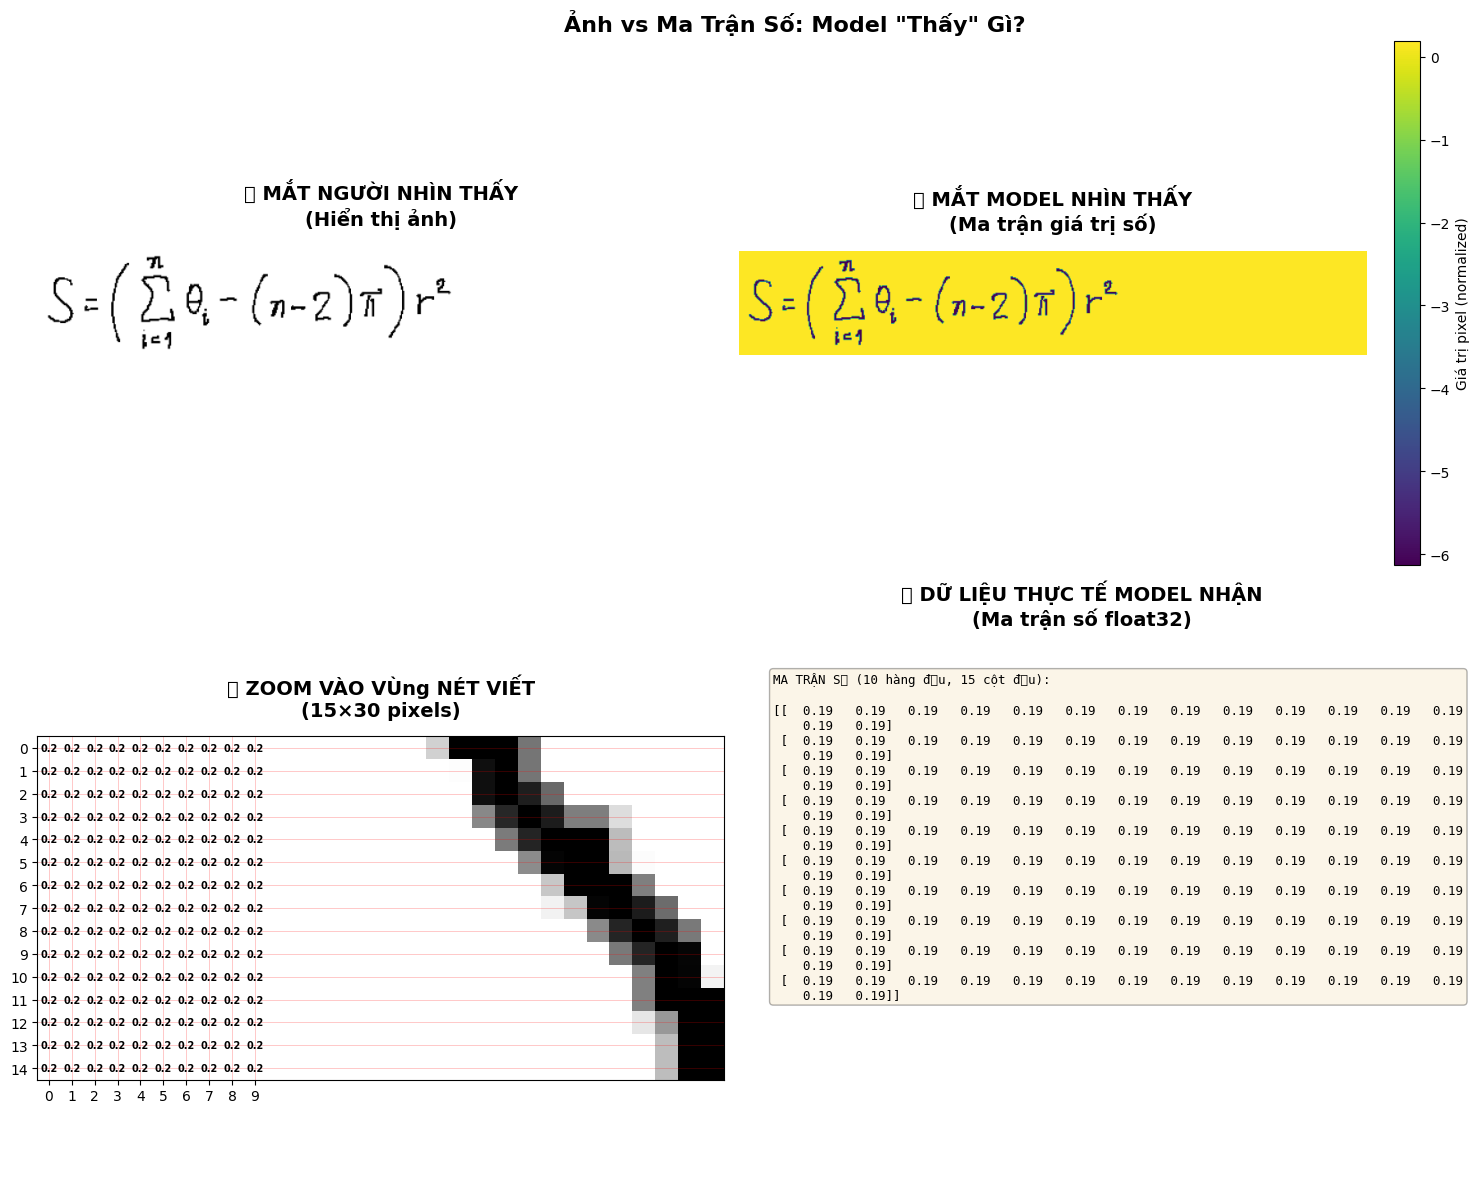


💡 GIẢI THÍCH VISUALIZATION:
TOP-LEFT:  Ảnh như bạn nhìn thấy (grayscale)
TOP-RIGHT: Ảnh với màu sắc theo giá trị số (heatmap)
           - Màu TÍM/XANH: Giá trị âm (nét viết)
           - Màu VÀNG:     Giá trị dương (nền trắng)

BOTTOM-LEFT:  Zoom vào 1 vùng nhỏ với GIÁ TRỊ SỐ hiển thị
              Model đọc CHÍNH XÁC những con số này!

BOTTOM-RIGHT: Ma trận số dạng text - đây là INPUT của model


In [3]:
# Visualization: So sánh giữa "mắt người" và "mắt model"
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ảnh như MẮT NGƯỜI thấy
axes[0, 0].imshow(preprocessed_img, cmap='gray')
axes[0, 0].set_title('👁️ MẮT NGƯỜI NHÌN THẤY\n(Hiển thị ảnh)', 
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 0].axis('off')

# 2. Ảnh như MẮT MODEL thấy (heatmap)
im = axes[0, 1].imshow(preprocessed_img, cmap='viridis')
axes[0, 1].set_title('🤖 MẮT MODEL NHÌN THẤY\n(Ma trận giá trị số)', 
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 1].axis('off')
plt.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04, 
             label='Giá trị pixel (normalized)')

# 3. Zoom vào một vùng nhỏ: Ma trận số
zoom_region = preprocessed_img[40:55, 100:130]  # Vùng có nét viết
axes[1, 0].imshow(zoom_region, cmap='gray', interpolation='nearest')
axes[1, 0].set_title('🔍 ZOOM VÀO VÙng NÉT VIẾT\n(15×30 pixels)', 
                     fontsize=14, fontweight='bold', pad=15)

# Hiển thị grid và giá trị số
for i in range(zoom_region.shape[0]):
    for j in range(min(10, zoom_region.shape[1])):  # Chỉ hiện 10 cột đầu
        value = zoom_region[i, j]
        color = 'white' if value < -1 else 'black'
        axes[1, 0].text(j, i, f'{value:.1f}', 
                       ha='center', va='center', 
                       fontsize=7, color=color, fontweight='bold')

axes[1, 0].set_xticks(range(min(10, zoom_region.shape[1])))
axes[1, 0].set_yticks(range(zoom_region.shape[0]))
axes[1, 0].grid(True, color='red', linewidth=0.5, alpha=0.3)

# 4. Ma trận số dạng text (góc trái trên)
sample_matrix = preprocessed_img[:10, :15]
matrix_text = "MA TRẬN SỐ (10 hàng đầu, 15 cột đầu):\n\n"
matrix_text += np.array2string(sample_matrix, 
                               formatter={'float_kind': lambda x: f"{x:6.2f}"},
                               max_line_width=100)

axes[1, 1].text(0.05, 0.95, matrix_text, 
               transform=axes[1, 1].transAxes,
               fontsize=9, verticalalignment='top',
               fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 1].set_title('📝 DỮ LIỆU THỰC TẾ MODEL NHẬN\n(Ma trận số float32)', 
                     fontsize=14, fontweight='bold', pad=15)
axes[1, 1].axis('off')

plt.suptitle('Ảnh vs Ma Trận Số: Model "Thấy" Gì?', 
            fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n💡 GIẢI THÍCH VISUALIZATION:")
print("="*70)
print("TOP-LEFT:  Ảnh như bạn nhìn thấy (grayscale)")
print("TOP-RIGHT: Ảnh với màu sắc theo giá trị số (heatmap)")
print("           - Màu TÍM/XANH: Giá trị âm (nét viết)")
print("           - Màu VÀNG:     Giá trị dương (nền trắng)")
print()
print("BOTTOM-LEFT:  Zoom vào 1 vùng nhỏ với GIÁ TRỊ SỐ hiển thị")
print("              Model đọc CHÍNH XÁC những con số này!")
print()
print("BOTTOM-RIGHT: Ma trận số dạng text - đây là INPUT của model")
print("="*70)

### Luồng xử lý: Từ ảnh → Model → LaTeX

In [4]:
print("="*80)
print("🔄 LUỒNG XỬ LÝ: TỪ ẢNH GỐC → MODEL → LATEX")
print("="*80)

print("\n📸 BƯỚC 1: ẢNH GỐC")
print("-" * 80)
print("  Input:  File ảnh .png/.jpg (ví dụ: '101_Nina.png')")
print("  Format: RGB/Grayscale, kích thước bất kỳ (ví dụ: 450×320)")
print("  Dữ liệu: Ma trận pixel với giá trị 0-255 (uint8)")
print()

print("🔧 BƯỚC 2: PREPROCESSING")
print("-" * 80)
print("  ① Grayscale:       RGB → Grayscale (3 channels → 1 channel)")
print("  ② Crop:            Cắt bỏ whitespace thừa (450×320 → 280×220)")
print("  ③ Resize:          Giữ tỉ lệ, scale về height=128 (280×220 → 158×128)")
print("  ④ Pad:             Thêm padding trắng về width=768 (158×128 → 768×128)")
print("  ⑤ Normalize:       Per-image normalize (mean=0, std=1)")
print()
print(f"  Output: Numpy array shape {preprocessed_img.shape}, dtype {preprocessed_img.dtype}")
print(f"  Lưu vào: .npy file (384 KB)")
print()

print("💾 BƯỚC 3: LƯU TRỮ & LOAD")
print("-" * 80)
print("  • File .npy chứa ma trận số CHÍNH XÁC như sau preprocessing")
print("  • Khi training: np.load('101_Nina.npy') → lấy ngay ma trận (128, 768)")
print("  • KHÔNG cần preprocess lại → Tiết kiệm thời gian!")
print()

print("🧠 BƯỚC 4: MODEL XỬ LÝ")
print("-" * 80)
print("  Input shape:  (batch_size, 1, 128, 768)")
print("                 ↑           ↑   ↑    ↑")
print("                 |           |   |    └─ Width (pixels)")
print("                 |           |   └────── Height (pixels)")
print("                 |           └────────── Channels (grayscale)")
print("                 └────────────────────── Số ảnh trong 1 batch")
print()
print("  Encoder (CNN):")
print("    • Convolutional layers: Trích xuất FEATURES từ ma trận pixel")
print("    • Học các PATTERN: nét cong, nét thẳng, góc, vòng tròn...")
print("    • Output: Feature maps (vectors đại diện cho ảnh)")
print()
print("  Decoder (Transformer/LSTM):")
print("    • Nhận features từ encoder")
print("    • Sinh ra LaTeX TỪNG TOKEN MỘT")
print("    • Ví dụ: ['\\\\frac', '{', 'x', '}', '{', '2', '}']")
print()

print("📝 BƯỚC 5: OUTPUT LATEX")
print("-" * 80)
print("  Output: Chuỗi LaTeX (ví dụ: '\\\\frac{x}{2} + y^2 = 0')")
print("  Render: Hiển thị công thức toán học")
print()

print("="*80)
print("🎯 TÓM TẮT: Model 'HIỂU' GÌ?")
print("="*80)
print("Model KHÔNG 'thấy' hình ảnh như con người!")
print("Model chỉ nhìn thấy: MÃ TRẬN SỐ (128×768 = 98,304 số float32)")
print()
print("Qua training, model học được:")
print("  ✓ Pattern trong ma trận → Ý nghĩa toán học")
print("  ✓ Vị trí pixel tối → Hình dạng ký tự")
print("  ✓ Cấu trúc không gian → Thứ tự ký hiệu")
print()
print("Ví dụ cụ thể:")
print("  • Ma trận có pixels tối tạo thành 'hình ngang' → Token: '-' ")
print("  • Ma trận có pixels tối tạo thành 'góc vuông' → Token: '\\\\sqrt'")
print("  • Pattern phức tạp hơn → Kết hợp nhiều token → Công thức hoàn chỉnh")
print("="*80)

🔄 LUỒNG XỬ LÝ: TỪ ẢNH GỐC → MODEL → LATEX

📸 BƯỚC 1: ẢNH GỐC
--------------------------------------------------------------------------------
  Input:  File ảnh .png/.jpg (ví dụ: '101_Nina.png')
  Format: RGB/Grayscale, kích thước bất kỳ (ví dụ: 450×320)
  Dữ liệu: Ma trận pixel với giá trị 0-255 (uint8)

🔧 BƯỚC 2: PREPROCESSING
--------------------------------------------------------------------------------
  ① Grayscale:       RGB → Grayscale (3 channels → 1 channel)
  ② Crop:            Cắt bỏ whitespace thừa (450×320 → 280×220)
  ③ Resize:          Giữ tỉ lệ, scale về height=128 (280×220 → 158×128)
  ④ Pad:             Thêm padding trắng về width=768 (158×128 → 768×128)
  ⑤ Normalize:       Per-image normalize (mean=0, std=1)

  Output: Numpy array shape (128, 768), dtype float32
  Lưu vào: .npy file (384 KB)

💾 BƯỚC 3: LƯU TRỮ & LOAD
--------------------------------------------------------------------------------
  • File .npy chứa ma trận số CHÍNH XÁC như sau preprocessing
  • Kh